In [1]:
# Модуль для збору відео-датасету
import cv2
import mediapipe as mp
import os
import json
import time
from datetime import datetime
import numpy as np

class VideoDatasetCollector:
    
    def __init__(self, path="dataset", duration=2, fps=30, min_hand_detection_rate=0.8, save_crops=False):
        self.path = path
        self.duration = duration
        self.fps = fps
        self.save_crops = save_crops
        self.min_hand_detection_rate = min_hand_detection_rate
        
        self.videos_path = os.path.join(path, "videos")
        self.frames_path = os.path.join(path, "frames")
        self.landmarks_path = os.path.join(path, "landmarks")
        
        os.makedirs(self.videos_path, exist_ok=True)
        os.makedirs(self.frames_path, exist_ok=True)
        os.makedirs(self.landmarks_path, exist_ok=True)
        
        if self.save_crops:
            self.crops_path = os.path.join(path, "rgb_crops")
            os.makedirs(self.crops_path, exist_ok=True)
        
        # Ініціалізація MediaPipe Hands
        self.mp_hands = mp.solutions.hands
        self.mp_drawing = mp.solutions.drawing_utils
        self.hands = self.mp_hands.Hands(
            static_image_mode=False,
            max_num_hands=1,
            min_detection_confidence=0.7,
            min_tracking_confidence=0.5
        )
        
        self.alphabet = ['А', 'Б', 'В', 'Г', 'Ґ', 'Д', 'Е', 'Є', 'Ж', 'З', 'И', 'І', 'Ї', 'Й', 'К', 'Л', 'М', 'Н', 'О', 'П', 'Р', 'С', 
                         'Т', 'У', 'Ф', 'Х', 'Ц', 'Ч', 'Ш', 'Щ', 'Ь', 'Ю', 'Я']
        
        self.metadata_file = os.path.join(path, "metadata.json")
        self.metadata = self.load_metadata()
        
        
    def load_metadata(self):
        if os.path.exists(self.metadata_file):
            with open(self.metadata_file, 'r', encoding='utf-8') as f:
                return json.load(f)
        return {"videos": [], "statistics": {}}
    
    def save_metadata(self):
        with open(self.metadata_file, 'w', encoding='utf-8') as f:
            json.dump(self.metadata, f, ensure_ascii=False, indent=2)
            

    # Запис відео 
    def wait_for_confirmation(self, cap, letter):
        print(f"Запис літери: {letter}")
        
        while True:
            ret, frame = cap.read()
            if not ret:
                continue
                
            frame = cv2.flip(frame, 1)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = self.hands.process(frame_rgb)
            
            # Відображення руки
            if results.multi_hand_landmarks:
                for hand_landmarks in results.multi_hand_landmarks:
                    self.mp_drawing.draw_landmarks(frame, hand_landmarks, self.mp_hands.HAND_CONNECTIONS)
                cv2.putText(frame, "Hand detected", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            else:
                cv2.putText(frame, "Show your hand", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
            
            cv2.putText(frame, f"Letter: {letter}", (50, 120), cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 255, 0), 3)
            cv2.putText(frame, "Space - record", (50, 200), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
            cv2.putText(frame, "S - skip", (50, 240), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
            cv2.putText(frame, "Q - quit", (50, 280), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
            
            cv2.imshow('Dataset Collection', frame)
            
            key = cv2.waitKey(1) & 0xFF
            if key == ord(' '):
                return 'record'
            elif key == ord('s') or key == ord('S'):
                return 'skip'
            elif key == ord('q') or key == ord('Q'):
                return 'quit'
    
    def record_video(self, letter, person_id="person1", video_num=1, auto_confirm=False):
        if letter not in self.alphabet:
            print(f"Error: '{letter}' не входить до української абетки")
            return False
        
        letter_folder = os.path.join(self.videos_path, letter)
        os.makedirs(letter_folder, exist_ok=True)
        
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        video_filename = f"{person_id}_vid{video_num}_{timestamp}.avi"
        video_path = os.path.join(letter_folder, video_filename)
        temp_video_path = video_path.replace('.avi', '_temp.avi')
        
        cap = cv2.VideoCapture(0)
        
        if not cap.isOpened():
            print("Error: не можливо відкрити камеру")
            return False
            
        cap.set(cv2.CAP_PROP_FPS, self.fps)
        
        frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        
        if not auto_confirm:
            action = self.wait_for_confirmation(cap, letter)
            if action == 'skip':
                print("Запис пропущено")
                cap.release()
                cv2.destroyAllWindows()
                return False
            elif action == 'quit':
                cap.release()
                cv2.destroyAllWindows()
                return 'quit'
        
        # Створення тимчасового файлу
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        out = cv2.VideoWriter(temp_video_path, fourcc, self.fps, (frame_width, frame_height))
        
        print(f"Запис відео для літери: {letter}")
        print(f"Диктор {person_id}, відео {video_num}")
        
        # Зворотний відлік
        for i in range(2, 0, -1):
            ret, frame = cap.read()
            if ret:
                frame = cv2.flip(frame, 1)
                cv2.putText(frame, f"Start in: {i}", (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 255), 3)
                cv2.putText(frame, f"Letter: {letter}", (50, 200), cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 0), 4)
                cv2.imshow('Dataset Collection', frame)
                cv2.waitKey(1000)
        
        # Запис відео
        print(f"\n Запис ({self.duration} секунд)")
        start_time = time.time()
        frame_count = 0
        frames_data = []
        
        while time.time() - start_time < self.duration:
            ret, frame = cap.read()
            if not ret:
                break
            
            frame = cv2.flip(frame, 1)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            # Виявлення руки
            results = self.hands.process(frame_rgb)
            
            # Відображення
            elapsed = time.time() - start_time
            remaining = self.duration - elapsed
            
            if results.multi_hand_landmarks:
                for hand_landmarks in results.multi_hand_landmarks:
                    self.mp_drawing.draw_landmarks(frame, hand_landmarks, self.mp_hands.HAND_CONNECTIONS)
                    
                    landmarks_data = []
                    for landmark in hand_landmarks.landmark:
                        landmarks_data.append({'x': landmark.x, 'y': landmark.y, 'z': landmark.z})
                    
                    frames_data.append({'frame_num': frame_count, 'timestamp': elapsed, 'landmarks': landmarks_data})
                
                cv2.putText(frame, "Hand detected!", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            else:
                cv2.putText(frame, "Hand not detected!", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
            
            cv2.putText(frame, f"Letter: {letter}", (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 0), 3)
            cv2.putText(frame, f"Remaining: {remaining:.1f}s", (50, 150), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
            
            bar_width = int((elapsed / self.duration) * (frame_width - 100))
            cv2.rectangle(frame, (50, frame_height - 50), (50 + bar_width, frame_height - 30), (0, 255, 0), -1)
            cv2.rectangle(frame, (50, frame_height - 50), (frame_width - 50, frame_height - 30), (255, 255, 255), 2)
            
            out.write(frame)
            cv2.imshow('Dataset Collection', frame)
            frame_count += 1
            
            if cv2.waitKey(1) & 0xFF == ord('q'):
                print("\nЗапис скасовано")
                cap.release()
                out.release()
                cv2.destroyAllWindows()
                os.remove(temp_video_path)
                return False
        
        cap.release()
        out.release()
        
        # Перевірка якості
        hand_detection_rate = len(frames_data) / frame_count if frame_count > 0 else 0
        
        print(f"Записано кадрів: {frame_count}")
        print(f"Кадрів з рукою: {len(frames_data)}")
        print(f"Частка розпізнавання руки: {hand_detection_rate*100:.1f}%")
        
        # Якщо якість низька
        if hand_detection_rate < self.min_hand_detection_rate:
            print(f"\nНизька якість відео")
            print(f"Рука була записана на {hand_detection_rate*100:.1f}% кадрах")
            print("Y - зберегти")
            print("N - видалити") 
            print("R - повторний запис")
            
            while True:
                choice = input("Your choice: ").lower()
                if choice == 'y':
                    print("Низька частка проігнорована")
                    break
                elif choice == 'n':
                    print("Відео видалено")
                    os.remove(temp_video_path)
                    cv2.destroyAllWindows()
                    return False
                elif choice == 'r':
                    print("Повторний запис")
                    os.remove(temp_video_path)
                    cv2.destroyAllWindows()
                    return self.record_video(letter, person_id, video_num, auto_confirm=False)
                else:
                    print("Помилка. Ввід лише y/n/r")
        else:
            print(f"\nВідео високої якості")
        
        # з temp на фінальний файл
        os.rename(temp_video_path, video_path)
        cv2.destroyAllWindows()
        
        print(f"Відео збережено за шляхом: {video_path}")
        
        # Збереження landmarks в JSON
        landmarks_filename = video_filename.replace('.avi', '_landmarks.json')
        landmarks_path = os.path.join(self.landmarks_path, letter)
        os.makedirs(landmarks_path, exist_ok=True)
        
        with open(os.path.join(landmarks_path, landmarks_filename), 'w') as f:
            json.dump(frames_data, f, indent=2, ensure_ascii=False)

        # landmarks в npz
        valid = []
        for f in frames_data:
            if len(f["landmarks"]) == 21:
                flat = []
                for lm in f["landmarks"]:
                    flat.extend([lm["x"], lm["y"], lm["z"]])
                valid.append((flat, f["timestamp"]))

        if not valid:
            return False

        T = len(valid)
        arr = np.zeros((T, 63), dtype=np.float32)
        ts = np.zeros((T,), dtype=np.float32)

        for i, (flat, t) in enumerate(valid):
            arr[i] = flat
            ts[i] = t

        npz_filename = video_filename.replace('.avi', '_landmarks.npz')
        npz_path = os.path.join(self.landmarks_path, letter, npz_filename)
        np.savez_compressed(
                npz_path,
                landmarks=arr,
                timestamps=ts,
                fps=self.fps,
                letter=letter,
                person_id=person_id
        )

        # Оновлення метаданих
        video_info = {
            'letter': letter,
            'type': 'static',
            'person_id': person_id,
            'video_num': video_num,
            'video_path': video_path,
            'landmarks_path': os.path.join(landmarks_path, landmarks_filename),
            'frame_count': frame_count,
            'frames_with_hand': len(frames_data),
            'hand_detection_rate': hand_detection_rate, 
            'timestamp': timestamp,
            'duration': self.duration,
            'fps': self.fps
        }
        self.metadata['videos'].append(video_info)
        
        # Оновлення статистики
        if letter not in self.metadata['statistics']:
            self.metadata['statistics'][letter] = 0
        self.metadata['statistics'][letter] += 1
        
        self.save_metadata()
        
        return True
    
    def collect_session(self, letters, person_id="person1", videos_per_letter=3, auto_confirm=False):
        print(f"Збір датасету")
        print(f"Літери: {', '.join(letters)}")
        print(f"Відео на літеру: {videos_per_letter}")
        print(f"Загальна кількість відео: {len(letters) * videos_per_letter}")
        
        total_videos = len(letters) * videos_per_letter
        completed = 0
        skipped = 0
        
        for letter in letters:
            for vid_num in range(1, videos_per_letter + 1):
                print(f"\n[{completed + skipped + 1}/{total_videos}]")
                
                result = self.record_video(letter, person_id, vid_num, auto_confirm)
                
                if result == 'quit':
                    return
                elif result:
                    completed += 1
                else:
                    skipped += 1
                
                if not auto_confirm and (completed + skipped) < total_videos:
                    print(f"\nПауза")
        
        print(f"Записано відео: {completed}/{total_videos}")
        print(f"Пропущено відео:  {skipped}")
        
        self.print_statistics()
    
    def print_statistics(self):
        print("Статистика датасету")
        
        total_videos = len(self.metadata['videos'])
        print(f"Загальна кількість відео: {total_videos}")
        
        if self.metadata['statistics']:
            print("\nВідео на літеру:")
            for letter in sorted(self.metadata['statistics'].keys()):
                count = self.metadata['statistics'][letter]
                print(f"  {letter}: {count} відео")
        

In [1]:
# Модуль для препроцессингу відео-датасету для розпізнавання дактильної абетки
import cv2
import mediapipe as mp
import os
import json
import numpy as np
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm import tqdm

class VideoDataProcessor:
    def __init__(self, dataset_path="ukrainian_sign_dataset"):
        self.dataset_path = dataset_path
        self.videos_path = os.path.join(dataset_path, "videos")
        self.frames_path = os.path.join(dataset_path, "frames")
        self.landmarks_path = os.path.join(dataset_path, "landmarks")
        self.processed_path = os.path.join(dataset_path, "processed")
        
        os.makedirs(self.frames_path, exist_ok=True)
        os.makedirs(self.processed_path, exist_ok=True)
        
        self.mp_hands = mp.solutions.hands
        self.hands = self.mp_hands.Hands(
            static_image_mode=False,
            max_num_hands=1,
            min_detection_confidence=0.7
        )
        
        self.metadata_file = os.path.join(dataset_path, "metadata.json")
        if os.path.exists(self.metadata_file):
            with open(self.metadata_file, 'r', encoding='utf-8') as f:
                self.metadata = json.load(f)
        else:
            self.metadata = {"videos": []}
    
    def extract_frames_from_video(self, video_path, output_folder, save_every_n_frames=1, max_frames=None):
        os.makedirs(output_folder, exist_ok=True)
        
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Помилка відкриття відео: {video_path}")
            return []
        
        frame_count = 0
        saved_count = 0
        saved_frames = []
        
        video_name = Path(video_path).stem
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            if frame_count % save_every_n_frames == 0:
                frame_filename = f"{video_name}_frame_{saved_count:04d}.jpg"
                frame_path = os.path.join(output_folder, frame_filename)
                
                cv2.imwrite(frame_path, frame)
                saved_frames.append(frame_path)
                saved_count += 1
                
                if max_frames and saved_count >= max_frames:
                    break
            
            frame_count += 1
        
        cap.release()
        return saved_frames

    @staticmethod
    def normalize_landmarks(hand_landmarks, flip_hand=False):
        base_x = hand_landmarks.landmark[0].x
        base_y = hand_landmarks.landmark[0].y
        base_z = hand_landmarks.landmark[0].z
    
        temp_landmarks = []
        for lm in hand_landmarks.landmark:
            x = lm.x - base_x
            y = lm.y - base_y
            z = lm.z - base_z
            if flip_hand:
                x = -x
            temp_landmarks.extend([x, y, z])
        
        landmarks_array = np.array(temp_landmarks)
        ref_x = hand_landmarks.landmark[9].x - base_x
        ref_y = hand_landmarks.landmark[9].y - base_y
        ref_z = hand_landmarks.landmark[9].z - base_z
        scale = np.sqrt(ref_x**2 + ref_y**2 + ref_z**2)
    
        if scale > 1e-6:
            landmarks_array = landmarks_array / scale

        return landmarks_array

    def extract_landmarks_from_frame(self, frame_path, flip_hand=False):
        image = cv2.imread(frame_path)
        if image is None: 
            return None
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        results = self.hands.process(image_rgb)
        if results.multi_hand_landmarks:
            return self.normalize_landmarks(results.multi_hand_landmarks[0], flip_hand)
        return None
    
    
    def process_all_videos(self, save_every_n_frames=2, max_frames_per_video=30):        
        stats = {
            'total_videos': 0,
            'processed_videos': 0,
            'total_frames': 0,
            'frames_with_hand': 0,
            'by_letter': {}
        }
        
        for letter_folder in os.listdir(self.videos_path):
            if letter_folder.startswith('.ipynb_checkpoints'): 
                continue
            letter_path = os.path.join(self.videos_path, letter_folder)
            
            if not os.path.isdir(letter_path):
                continue
            
            letter = letter_folder
            stats['by_letter'][letter] = {
                'videos': 0,
                'frames': 0,
                'frames_with_hand': 0
            }
            
            frames_letter_path = os.path.join(self.frames_path, letter)
            os.makedirs(frames_letter_path, exist_ok=True)
            
            video_files = [f for f in os.listdir(letter_path) if f.endswith('.avi')]
            
            print(f"\nОбробка літери '{letter}': {len(video_files)} відео")
            
            for video_file in tqdm(video_files, desc=f"Літера {letter}"):
                video_path = os.path.join(letter_path, video_file)
                
                saved_frames = self.extract_frames_from_video(video_path, frames_letter_path, save_every_n_frames, max_frames_per_video)
                
                stats['total_videos'] += 1
                stats['by_letter'][letter]['videos'] += 1
                
                if saved_frames:
                    stats['processed_videos'] += 1
                    stats['total_frames'] += len(saved_frames)
                    stats['by_letter'][letter]['frames'] += len(saved_frames)
        
        print(f"Оброблено відео: {stats['processed_videos']}/{stats['total_videos']}")
        print(f"Загальна кількість кадрів: {stats['total_frames']}")
        print(f"\nПо літерах:")
        for letter, data in stats['by_letter'].items():
            print(f" {letter}: {data['videos']} відео - {data['frames']} кадрів")
        
        return stats
    

    def create_dataset(self, sequence_length=20, step=2, output_file="training_data_lstm.npz",
                       test_size=0.2, random_state=42, use_velocity=True):

        letters = sorted([d for d in os.listdir(self.frames_path)
                          if os.path.isdir(os.path.join(self.frames_path, d)) and not d.startswith('.')])
        letter_to_idx = {l: i for i, l in enumerate(letters)}
    
        all_video_groups = []
        for letter in letters:
            letter_path = os.path.join(self.frames_path, letter)
            all_frames = sorted([f for f in os.listdir(letter_path) if f.endswith('.jpg')])
            video_groups = {}
            for f in all_frames:
                vname = f.split('_frame_')[0]
                video_groups.setdefault(vname, []).append(f)
            for vname, frames in video_groups.items():
                all_video_groups.append((letter, vname, frames))
    
        
        video_labels = [letter_to_idx[g[0]] for g in all_video_groups]
        train_groups, test_groups = train_test_split(
            all_video_groups, test_size=test_size,
            random_state=random_state, stratify=video_labels
        )
        train_labels_for_split = [letter_to_idx[g[0]] for g in train_groups]
        train_groups, val_groups = train_test_split(
            train_groups, test_size=0.1,
            random_state=random_state, stratify=train_labels_for_split
        )

        def add_velocity(seq_array):
            velocity = np.zeros_like(seq_array)
            velocity[1:] = seq_array[1:] - seq_array[:-1]
            return np.concatenate([seq_array, velocity], axis=-1)

        def groups_to_sequences(groups):
            X, y = [], []
            for letter, vname, frames in tqdm(groups, desc="Обробка"):
                letter_path = os.path.join(self.frames_path, letter)
                seq = []
                for f_name in frames:
                    lm = self.extract_landmarks_from_frame(os.path.join(letter_path, f_name))
                    if lm is not None:
                        seq.append(lm)

                if len(seq) == 0:
                    continue
                seq_array = np.array(seq, dtype=np.float32)
                
                if use_velocity:
                    seq_array = add_velocity(seq_array)

                T = len(seq_array)
                feat_dim = seq_array.shape[1] 
                
                if T >= sequence_length:
                    for i in range(0, T - sequence_length + 1, step):
                        X.append(seq_array[i:i + sequence_length])
                        y.append(letter_to_idx[letter])
                elif T >= sequence_length // 2:
                    # padding останнім кадром
                    pad_count = sequence_length - T
                    pad = np.tile(seq_array[-1:], (pad_count, 1))
                    padded = np.concatenate([seq_array, pad], axis=0) 
                    X.append(padded)
                    y.append(letter_to_idx[letter])
                
            return X, y
    
        print("Train відео")
        X_tr, y_tr = groups_to_sequences(train_groups)
        print("Val відео")
        X_v, y_v = groups_to_sequences(val_groups)
        print("Test відео")
        X_te, y_te = groups_to_sequences(test_groups)
    
        X_train = np.stack(X_tr).astype('float32')
        X_val   = np.stack(X_v).astype('float32')
        X_test  = np.stack(X_te).astype('float32')
        y_train = np.array(y_tr).astype('int32')
        y_val   = np.array(y_v).astype('int32')
        y_test  = np.array(y_te).astype('int32')

        feature_dim = X_train.shape[-1]
        print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
        print(f"Feature dim: {feature_dim} ({'з velocity' if use_velocity else 'без velocity'})")
    
        output_path = os.path.join(self.processed_path, output_file)
        np.savez(output_path,
                 X_train=X_train, X_val=X_val, X_test=X_test,
                 y_train=y_train, y_val=y_val, y_test=y_test,
                 mapping=letter_to_idx)
    
        return X_train, X_val, X_test, y_train, y_val, y_test

In [3]:
# Запис даних
if __name__ == "__main__":

    collector = VideoDatasetCollector(
        path="ukrainian_sign_dataset",
        duration=2,
        fps=30,
        min_hand_detection_rate=0.9
    )

    # letters_to_record = ['А', 'Б', 'В', 'Г', 'Е', 'Ж', 'И', 'І', 'Л', 'М', 'Н', 'О', 'П', 'Р', 'С', 'Т', 'У', 'Ф', 'Х', 'Ч', 'Ш', 'Ю', 'Я']
    , 
    letters_to_record = ['Ь'] 
    collector.collect_session(
        letters=letters_to_record,
        person_id='person1',
        videos_per_letter=25, 
        auto_confirm=False
    )

I0000 00:00:1778792712.924228 4076278 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M3
W0000 00:00:1778792712.933207 4089426 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778792712.940503 4089426 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Збір датасету
Літери: Ь
Відео на літеру: 25
Загальна кількість відео: 25
Режим: З підтвердженням

[1/25]
Запис літери: Ь
Запис відео для літери: Ь
Людина person1, відео Nr: 1

 Запис (2 секунд)
Записано кадрів: 31
Кадрів з рукою: 31
Частка розпізнавання руки: 100.0%

Відео високої якості
Відео збережено за шляхом: ukrainian_sign_dataset/videos/Ь/person1_vid1_20260514_230512.avi

Пауза

[2/25]
Запис літери: Ь
Запис відео для літери: Ь
Людина person1, відео Nr: 2

 Запис (2 секунд)
Записано кадрів: 31
Кадрів з рукою: 31
Частка розпізнавання руки: 100.0%

Відео високої якості
Відео збережено за шляхом: ukrainian_sign_dataset/videos/Ь/person1_vid2_20260514_230535.avi

Пауза

[3/25]
Запис літери: Ь
Запис відео для літери: Ь
Людина person1, відео Nr: 3

 Запис (2 секунд)
Записано кадрів: 31
Кадрів з рукою: 31
Частка розпізнавання руки: 100.0%

Відео високої якості
Відео збережено за шляхом: ukrainian_sign_dataset/videos/Ь/person1_vid3_20260514_230542.avi

Пауза

[4/25]
Запис літери: Ь
Запис 

In [2]:
processor = VideoDataProcessor("ukrainian_sign_dataset")

processor.process_all_videos(
    save_every_n_frames=1,
    max_frames_per_video=60
)

dataset = processor.create_dataset(
    sequence_length=25,
    step=1,
    output_file="training_data_lstm_25_1_v2.npz",
    test_size=0.2
)

I0000 00:00:1781081476.978919  471079 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M3



Обробка літери 'І': 65 відео


Літера І:   0%|                                          | 0/65 [00:00<?, ?it/s]INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1781081477.002269  473047 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781081477.007617  473047 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Літера І: 100%|█████████████████████████████████| 65/65 [00:09<00:00,  7.07it/s]



Обробка літери 'Б': 65 відео


Літера Б: 100%|█████████████████████████████████| 65/65 [00:09<00:00,  7.14it/s]


...

Val відео


Обробка: 100%|████████████████████████████████| 172/172 [01:19<00:00,  2.16it/s]


Test відео


Обробка: 100%|████████████████████████████████| 429/429 [03:16<00:00,  2.18it/s]

Train: (7855, 25, 126), Val: (891, 25, 126), Test: (2196, 25, 126)
Feature dim: 126 (з velocity)


Ці два компоненти описують 86.00% розкиду даних (PC1: 79.60%, PC2: 6.40%)


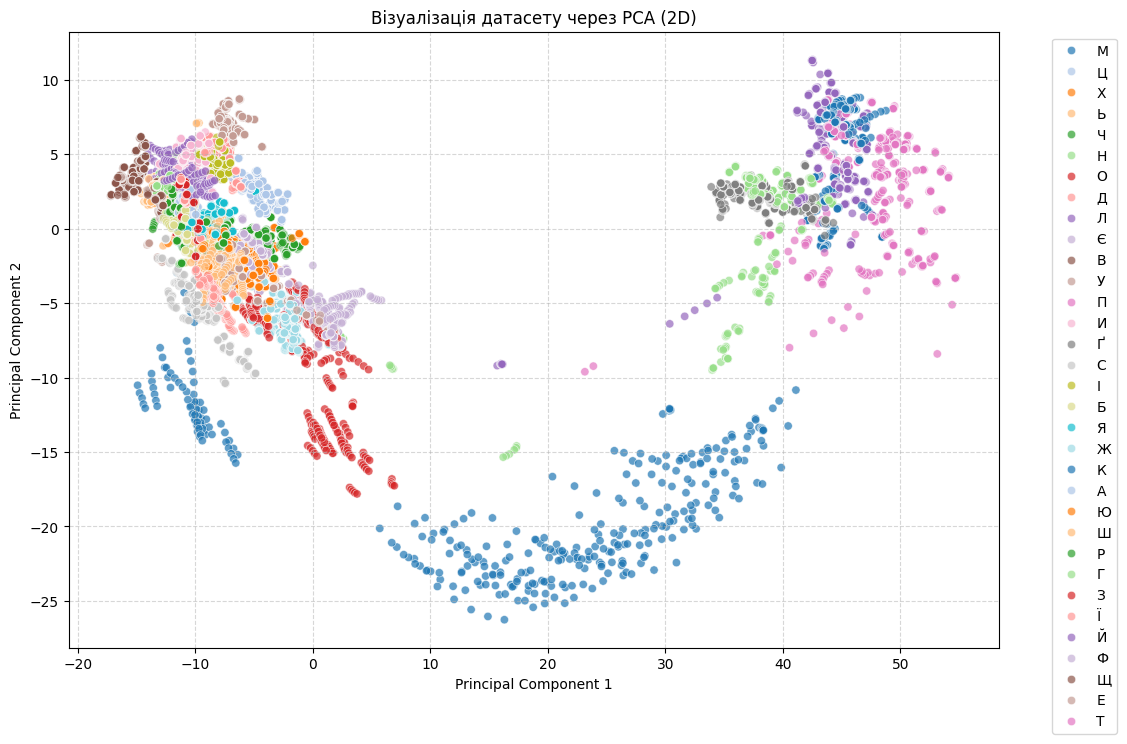

In [4]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = np.load("ukrainian_sign_dataset/processed/training_data_lstm.npz", allow_pickle=True)
X_train = data['X_train'].reshape(data['X_train'].shape[0], -1)
X_test = data['X_test'].reshape(data['X_test'].shape[0], -1)
X_val = data['X_val'].reshape(data['X_val'].shape[0], -1)
X_full = np.concatenate([X_train, X_val, X_test], axis=0)
y_full = np.concatenate([data['y_train'], data['y_val'], data['y_test']], axis=0)
y_train = data['y_train']
mapping = data['mapping'].item()

# з 3D в 2D)
if X_full.ndim > 2:
    X_full = X_full.reshape(X_full.shape[0], -1)
    
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_full)
exp_var = pca.explained_variance_ratio_ * 100
print(f"Ці два компоненти описують {np.sum(exp_var):.2f}% розкиду даних (PC1: {exp_var[0]:.2f}%, PC2: {exp_var[1]:.2f}%)")
    
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
    
inv_map = {v: k for k, v in mapping.items()} if isinstance(list(mapping.keys())[0], str) else mapping
    
pca_df['Letter'] = [inv_map.get(int(label), f"ID {label}") for label in y_full]
    
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Principal Component 1', 
    y='Principal Component 2', 
    hue='Letter', 
    data=pca_df, 
    palette='tab20',
    alpha=0.7
    )
    
plt.title('Візуалізація датасету через PCA (2D)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

t-SNE для 10942 зразків


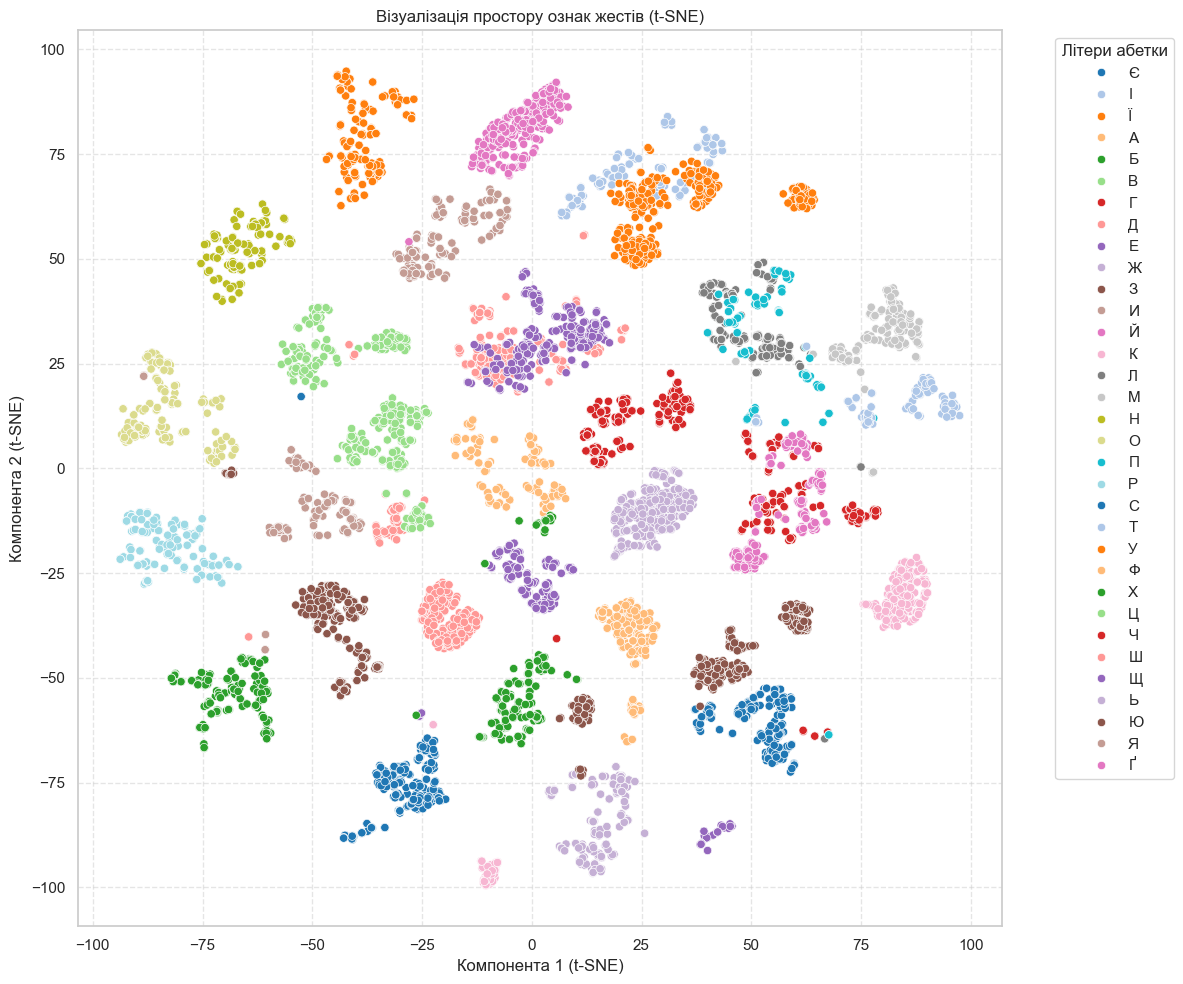

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

data = np.load('ukrainian_sign_dataset/processed/training_data_lstm.npz', allow_pickle=True)

X_full = np.concatenate([data['X_train'], data['X_val'], data['X_test']], axis=0)
y_full = np.concatenate([data['y_train'], data['y_val'], data['y_test']], axis=0)
mapping = data['mapping'].item()

num_samples = min(len(X_full), 15000)
indices = np.random.choice(len(X_full), num_samples, replace=False)

X_subset = X_full[indices]
y_subset = y_full[indices]

X_subset_flat = X_subset.reshape(num_samples, -1)

inv_map = {v: k for k, v in mapping.items()}

print(f"t-SNE для {num_samples} зразків")

tsne = TSNE(
    n_components=2, 
    perplexity=30, 
    random_state=42,
    learning_rate='auto',
    init='pca' 
)
X_tsne = tsne.fit_transform(X_subset_flat)

labels_ukr = [inv_map.get(int(i), f"ID {i}") for i in y_subset]

df = pd.DataFrame({
    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1],
    'Літера': labels_ukr
})
df = df.sort_values('Літера')

plt.figure(figsize=(12, 10))

ax = sns.scatterplot(
    data=df,
    x='TSNE1',
    y='TSNE2',
    hue='Літера',
    palette='tab20'
)

plt.title('Візуалізація простору ознак жестів (t-SNE)')
plt.xlabel('Компонента 1 (t-SNE)')
plt.ylabel('Компонента 2 (t-SNE)')

plt.legend(title='Літери абетки', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Epoch 1/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.2067 - loss: 3.0494 - val_accuracy: 0.4669 - val_loss: 2.8612 - learning_rate: 1.0000e-04
Epoch 2/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5129 - loss: 1.7022 - val_accuracy: 0.7587 - val_loss: 1.7594 - learning_rate: 1.0000e-04
Epoch 3/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6607 - loss: 1.2259 - val_accuracy: 0.8597 - val_loss: 0.8462 - learning_rate: 1.0000e-04
Epoch 4/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7556 - loss: 0.9374 - val_accuracy: 0.9371 - val_loss: 0.4353 - learning_rate: 1.0000e-04
Epoch 5/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8029 - loss: 0.7392 - val_accuracy: 0.9102 - val_loss: 0.3128 - learning_rate: 1.0000e-04
Epoch 6/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8251 - loss: 0.6514 - val_accuracy: 0.9226 - val_loss: 0.2504 - learning_rate: 1.0000e-04
Epoch 7/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - acc

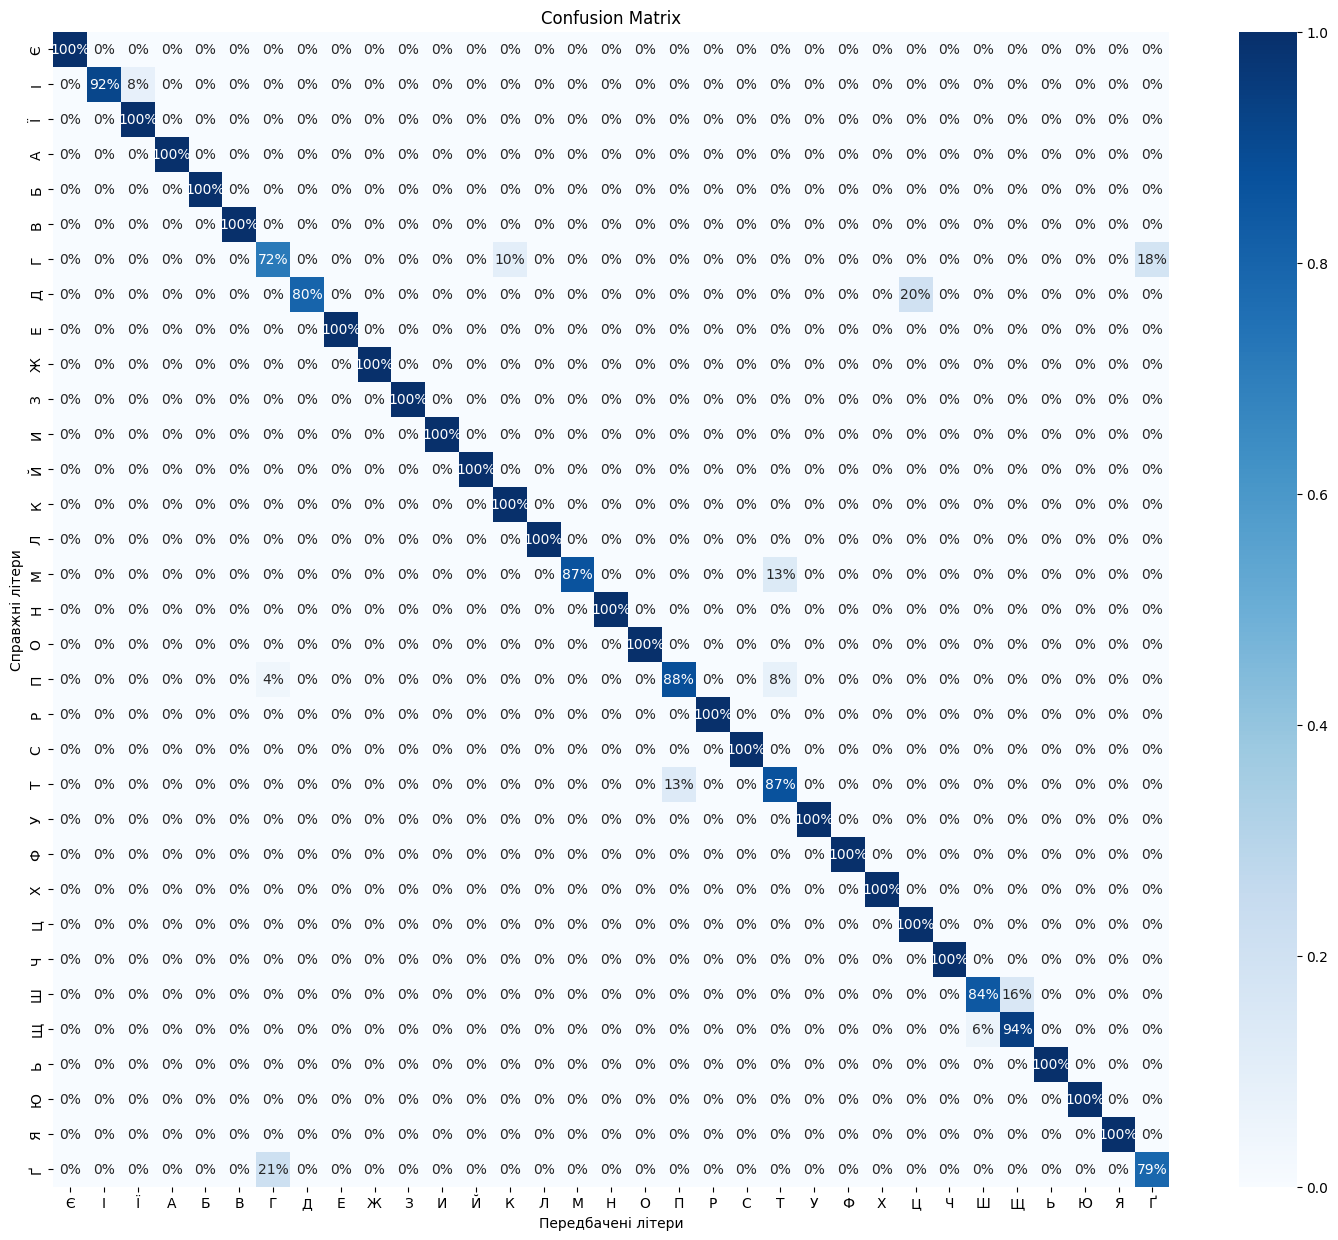

In [4]:
import numpy as np
import json
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, GaussianNoise, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.optimizers import Adam

data = np.load("ukrainian_sign_dataset/processed/training_data_lstm.npz", allow_pickle=True)
X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']

model = Sequential([
    Input(shape=(20, 126)),
    GaussianNoise(0.01),
    
    #Bidirectional(LSTM(128, return_sequences=True)),
    LSTM(128, return_sequences=True),
    BatchNormalization(),
    Dropout(0.25),
    
    #Bidirectional(LSTM(64, return_sequences=False)),
    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.25),
    
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(33, activation='softmax')
])

optimizer = Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer, 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=25, restore_best_weights=True, monitor='val_loss', verbose=1),
    ReduceLROnPlateau(factor=0.2, patience=4, monitor='val_loss', verbose=1)
]

mapping = data['mapping'].item()

weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(weights))
h_idx = mapping.get('Г', None)
g_idx = mapping.get('Ґ', None)
max_weight = max(class_weight_dict[h_idx], class_weight_dict[g_idx])
class_weight_dict[h_idx] = max_weight * 1.9
class_weight_dict[g_idx] = max_weight * 0.9

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weight_dict, 
    verbose=1
)
    
X_test = data['X_test']
y_test = data['y_test']
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nТочність на тестових даних: {test_acc*100:.2f}%")

In [5]:
model.save("sign_language_lstm_model_v20.keras")
model.save("sign_language_lstm_model_v20.h5")
print("Модель збережена")
with open("training_history_v20.json", "w") as f:
    json.dump(history.history, f)

Модель успішно навчена та збережена!


I0000 00:00:1779272471.567057  710054 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1779272471.567075  710054 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



Точність на тестових даних: 97.59%


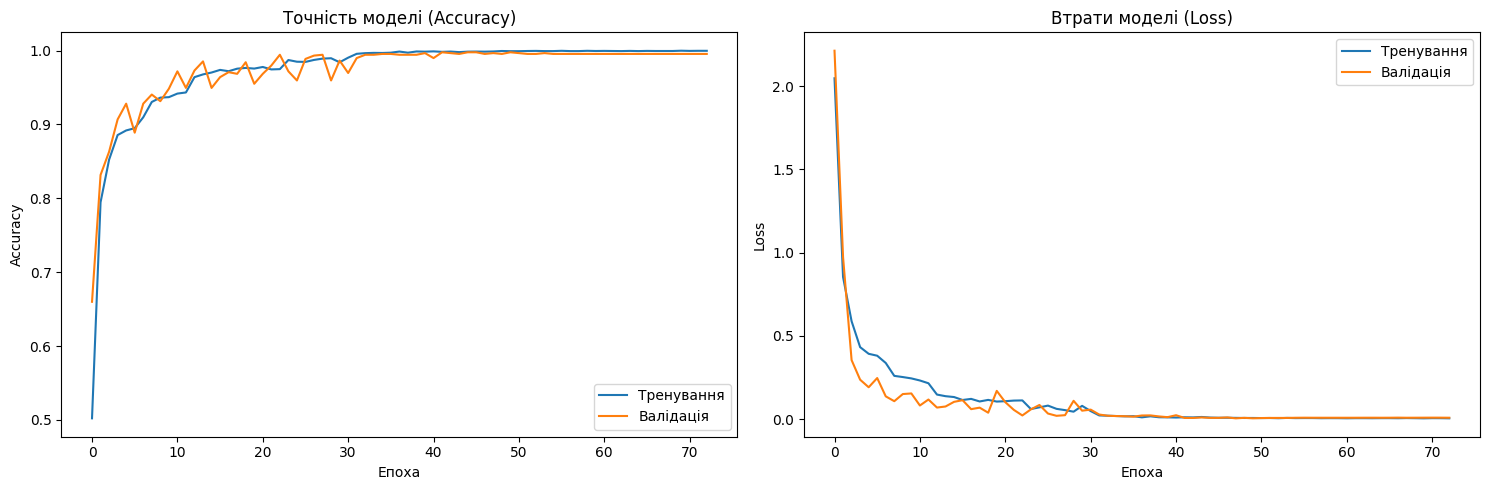

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step


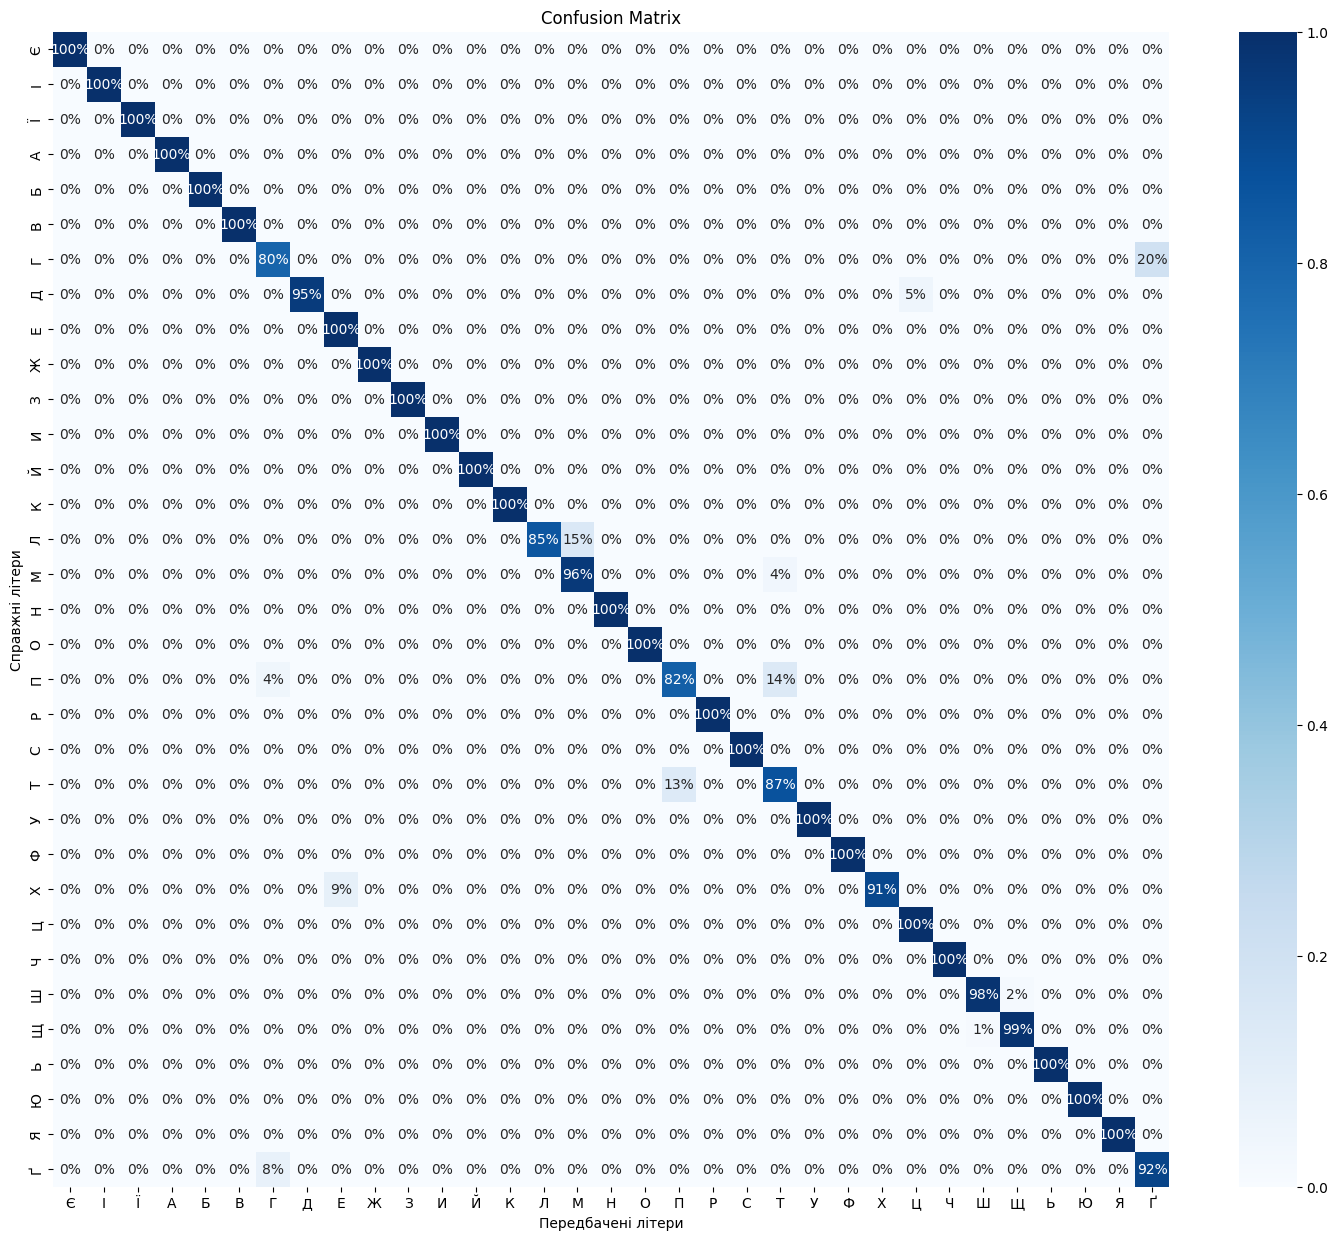


Детальний звіт по метриках:
              precision    recall  f1-score   support

           Є       1.00      1.00      1.00        69
           І       1.00      1.00      1.00        71
           Ї       1.00      1.00      1.00        76
           А       1.00      1.00      1.00        66
           Б       1.00      1.00      1.00        70
           В       1.00      1.00      1.00        69
           Г       0.89      0.80      0.84        60
           Д       1.00      0.95      0.98        65
           Е       0.92      1.00      0.96        68
           Ж       1.00      1.00      1.00        76
           З       1.00      1.00      1.00        61
           И       1.00      1.00      1.00        78
           Й       1.00      1.00      1.00        64
           К       1.00      1.00      1.00        71
           Л       1.00      0.85      0.92        62
           М       0.85      0.96      0.90        52
           Н       1.00      1.00      1.00        6

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import tensorflow as tf

model = tf.keras.models.load_model("sign_language_lstm_model_v11_9759.h5")
data = np.load("ukrainian_sign_dataset/processed/training_data_lstm.npz", allow_pickle=True)
with open("training_history_v11.json", "r") as f:
    history_data = json.load(f)

X_test = data['X_test']
y_test = data['y_test']
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nТочність на тестових даних: {test_acc*100:.2f}%")

# Loss & Accuracy
def plot_history(history_dict):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(history_dict['accuracy'], label='Тренування')
    ax1.plot(history_dict['val_accuracy'], label='Валідація')
    ax1.set_title('Точність моделі (Accuracy)')
    ax1.set_xlabel('Епоха')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax2.plot(history_dict['loss'], label='Тренування')
    ax2.plot(history_dict['val_loss'], label='Валідація')
    ax2.set_title('Втрати моделі (Loss)')
    ax2.set_xlabel('Епоха')
    ax2.set_ylabel('Loss')
    ax2.legend()
    plt.tight_layout()
    plt.show()

plot_history(history_data)

# Конфузійна матриця
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

mapping = data['mapping'].item()
target_names = [l for l, i in sorted(mapping.items(), key=lambda x: x[1])]

def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(18, 15))
    sns.heatmap(cm_normalized, annot=True, fmt='.0%', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('Справжні літери')
    plt.xlabel('Передбачені літери')
    plt.show()

plot_confusion_matrix(y_test, y_pred, target_names)

# Precision, Recall, F1-score
print("\nДетальний звіт по метриках:")
print(classification_report(y_test, y_pred, target_names=target_names))

Вхідна розмірність даних: (25, 126)

Старт навчання 1D CNN моделі...
Epoch 1/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7389 - loss: 0.8907 - val_accuracy: 0.5915 - val_loss: 1.5731 - learning_rate: 0.0010
Epoch 2/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8947 - loss: 0.3205 - val_accuracy: 0.8597 - val_loss: 0.6543 - learning_rate: 0.0010
Epoch 3/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9195 - loss: 0.2346 - val_accuracy: 0.8620 - val_loss: 0.3675 - learning_rate: 0.0010
Epoch 4/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9365 - loss: 0.1949 - val_accuracy: 0.9360 - val_loss: 0.1764 - learning_rate: 0.0010
Epoch 5/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9519 - loss: 0.1442 - val_accuracy: 0.9371 - val_loss: 0.1555 - learning_rate: 0.0010
Epoch 6/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9627 - loss: 0.1203 - val_accuracy: 0.9630 - val_loss: 0.1073 - learning_rate: 0.0010
Epoch 7

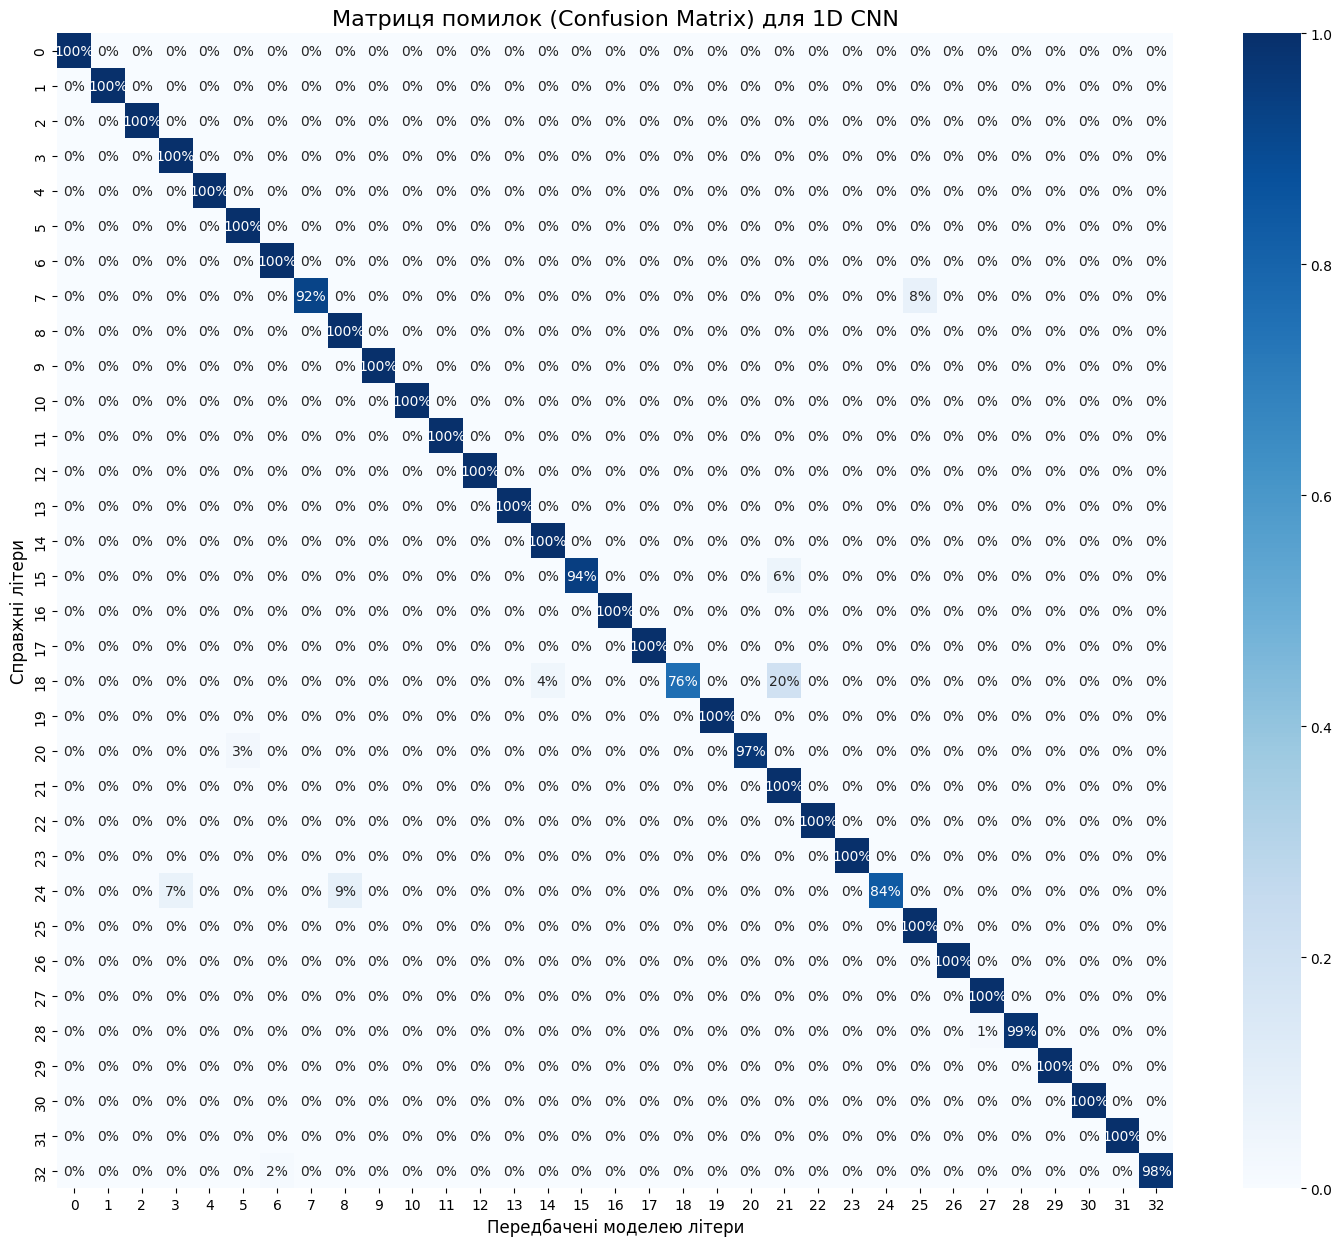

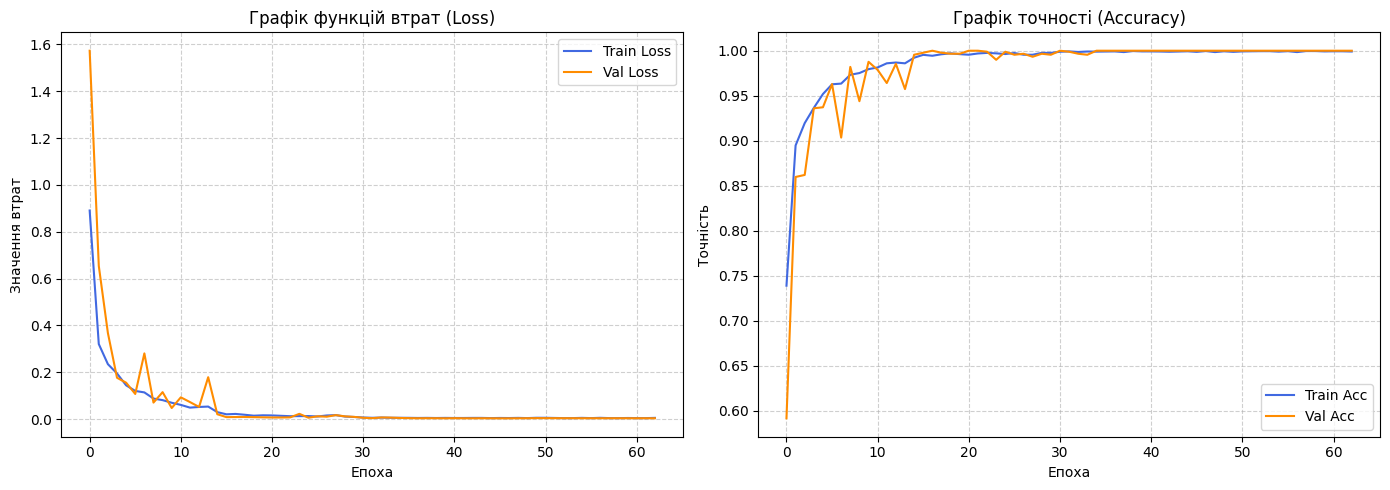

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GaussianNoise, Conv1D, BatchNormalization, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight

data = np.load("ukrainian_sign_dataset/processed/training_data_lstm.npz", allow_pickle=True)
X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']

letter_to_idx = data['mapping'].item() 

feature_dim = X_train.shape[-1] 

model_cnn = Sequential([
    Input(shape=(25, feature_dim)),
    GaussianNoise(0.01),
    
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.25),
    
    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.25),
    
    Flatten(),
    
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(33, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model_cnn.compile(
    optimizer=optimizer, 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

unique_classes = np.unique(y_train)
computed_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train
)

class_weights = {int(cls): float(weight) for cls, weight in zip(unique_classes, computed_weights)}

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=16, 
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.3, 
        patience=4
    )
]

print("\nСтарт навчання 1D CNN моделі")
history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X_test = data['X_test']
y_test = data['y_test']
X_val = data['X_val']
y_val = data['y_val']
test_loss, test_acc = model_cnn.evaluate(X_test, y_test, verbose=0)
val_loss, val_acc = model_cnn.evaluate(X_val, y_val, verbose=0)
print(f"\nТочність на тестових даних: {test_acc*100:.2f}%")
print(test_loss)
print(f"\nТочність на валідаційних даних: {val_acc*100:.2f}%")
print(val_loss)

idx_to_letter = {int(v): k for k, v in letter_to_idx.items()}
target_names = [idx_to_letter[i] for i in sorted(idx_to_letter.keys())]

print("Генерація прогнозів для тестового датасету...")
y_pred_probs = model_cnn.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)
print("\n" + "="*50)
print(f" Точність 1D CNN на тестовій вибірці (Accuracy): {test_accuracy*100:.2f}%")
print("="*50 + "\n")

print("Детальні метрики по класах:")
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(18, 15))
sns.heatmap(cm_normalized, annot=True, fmt='.0%', cmap='Blues')
plt.title('Матриця помилок (Confusion Matrix) для 1D CNN', fontsize=16)
plt.ylabel('Справжні літери', fontsize=12)
plt.xlabel('Передбачені моделею літери', fontsize=12)
plt.grid(False)
plt.show()

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='Train Loss', color='royalblue')
plt.plot(history_cnn.history['val_loss'], label='Val Loss', color='darkorange')
plt.title('Графік функцій втрат (Loss)')
plt.xlabel('Епоха')
plt.ylabel('Значення втрат')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['accuracy'], label='Train Acc', color='royalblue')
plt.plot(history_cnn.history['val_accuracy'], label='Val Acc', color='darkorange')
plt.title('Графік точності (Accuracy)')
plt.xlabel('Епоха')
plt.ylabel('Точність')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [9]:
import json
model_cnn.save("sign_language_cnn_model_kern9.keras")
model_cnn.save("sign_language_cnn_model_kern9.h5")
print("Модель успішно навчена та збережена!")
with open("training_history_cnn_kern9.json", "w") as f:
    json.dump(history_cnn.history, f)

Модель успішно навчена та збережена!



Точність на тестових даних: 99.00%
0.03332769125699997

Точність на валідаційних даних: 100.00%
0.0031222717370837927


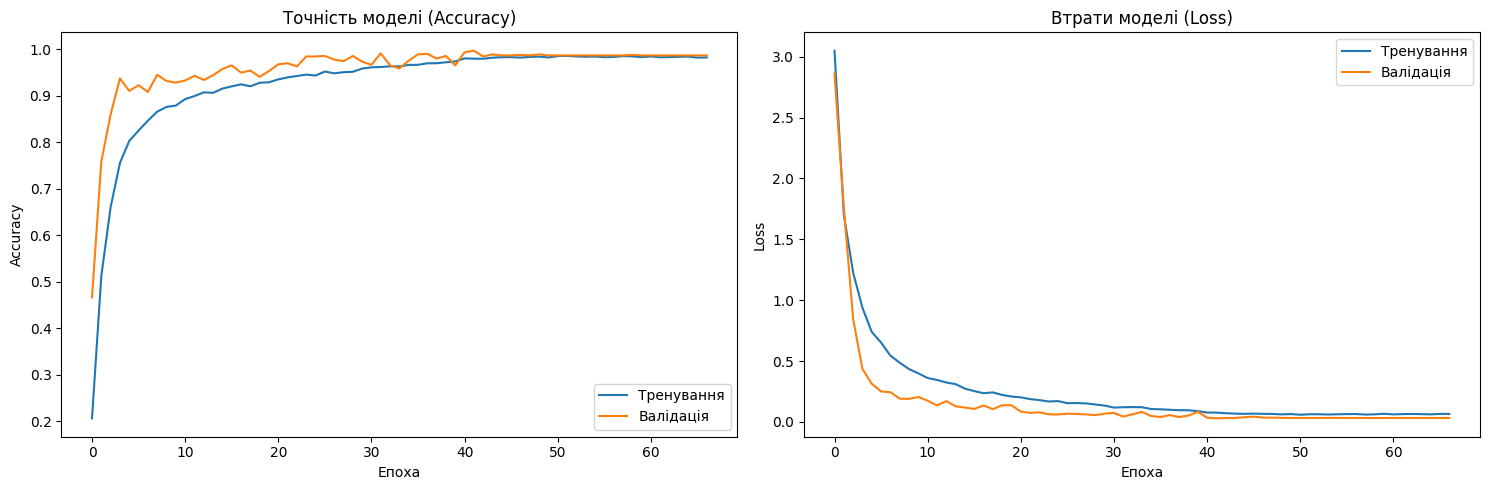

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


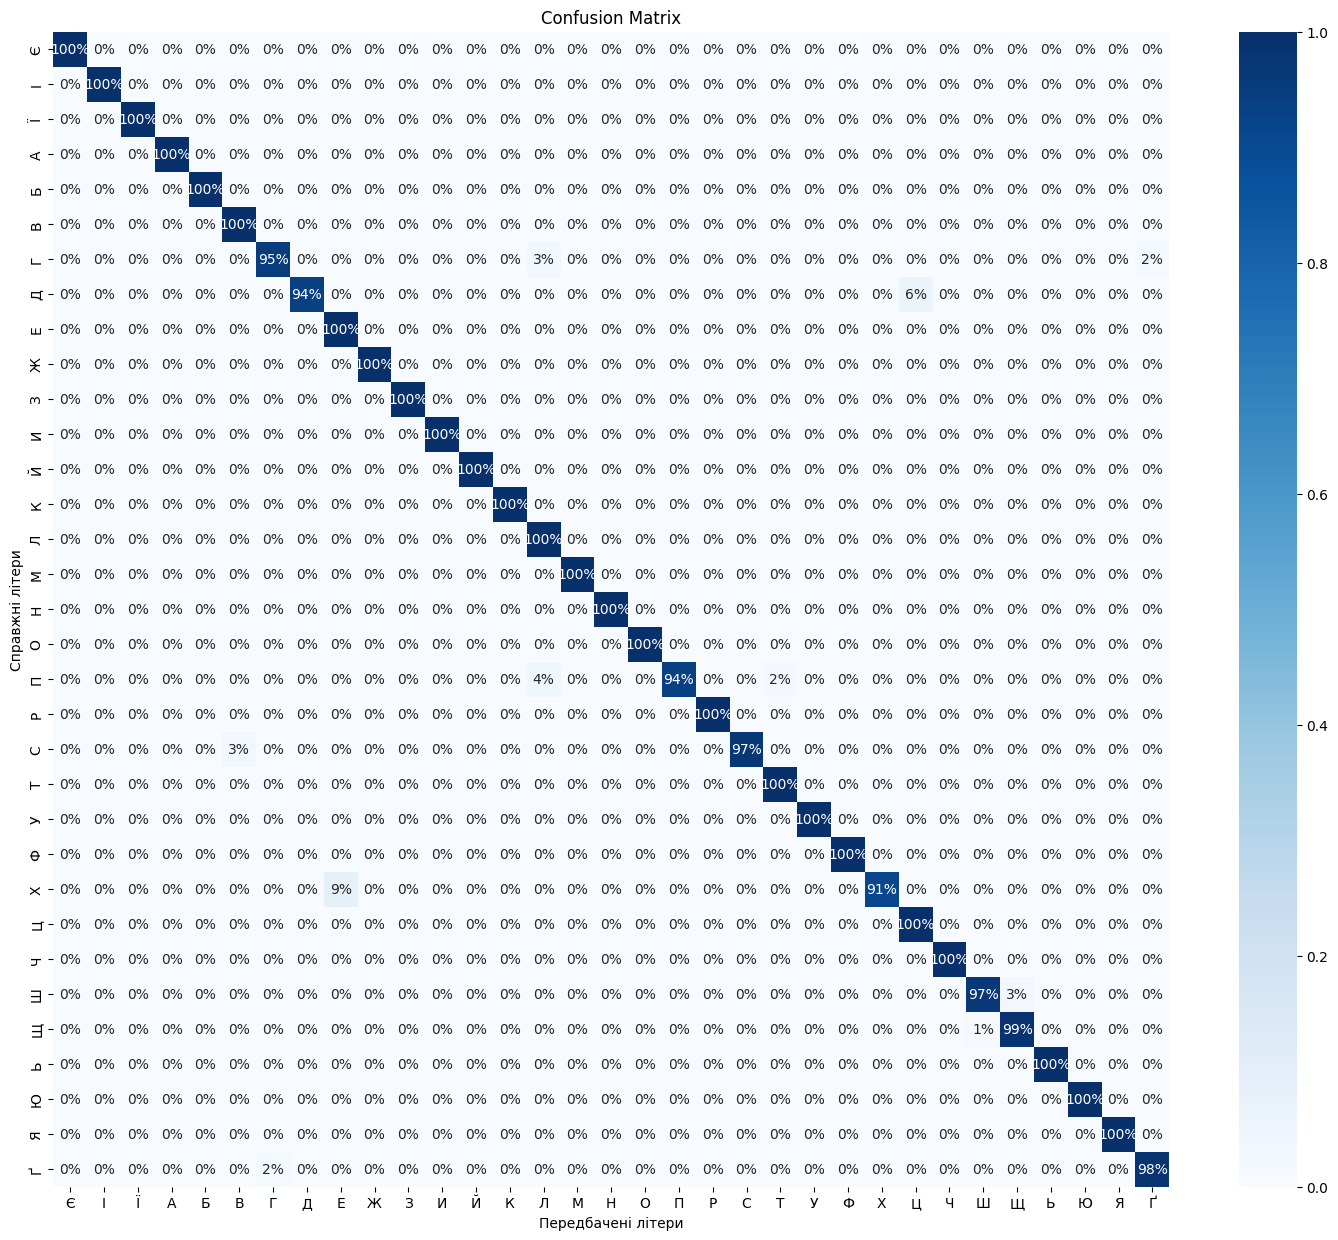


Детальний звіт по метриках:
              precision    recall  f1-score   support

           Є       1.00      1.00      1.00        69
           І       1.00      1.00      1.00        71
           Ї       1.00      1.00      1.00        76
           А       1.00      1.00      1.00        66
           Б       1.00      1.00      1.00        70
           В       0.97      1.00      0.99        69
           Г       0.98      0.95      0.97        60
           Д       1.00      0.94      0.97        65
           Е       0.92      1.00      0.96        68
           Ж       1.00      1.00      1.00        76
           З       1.00      1.00      1.00        61
           И       1.00      1.00      1.00        78
           Й       1.00      1.00      1.00        64
           К       1.00      1.00      1.00        71
           Л       0.94      1.00      0.97        62
           М       1.00      1.00      1.00        52
           Н       1.00      1.00      1.00        6

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise_34               │ (None, 25, 126)        │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_44 (Conv1D)              │ (None, 25, 64)         │        24,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_136         │ (None, 25, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_136 (Dropout)           │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_45 (Conv1D)              │ (None, 25, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_137         │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_137 (Dropout)           │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_22 (Flatten)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_102 (Dense)               │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_138         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_138 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_139         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_139 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ (None, 33)             │         4,257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 907,875 (3.46 MB)

 Trainable params: 906,721 (3.46 MB)

 Non-trainable params: 1,152 (4.50 KB)

 Optimizer params: 2 (12.00 B)

Модель навчалася 67 епох.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import tensorflow as tf

model = tf.keras.models.load_model("sign_language_cnn_model_v3.h5")
data = np.load("ukrainian_sign_dataset/processed/training_data_lstm.npz", allow_pickle=True)
with open("training_history_v20.json", "r") as f:
    history_data = json.load(f)

X_test = data['X_test']
y_test = data['y_test']
X_val = data['X_val']
y_val = data['y_val']
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"\nТочність на тестових даних: {test_acc*100:.2f}%")
print(test_loss)
print(f"\nТочність на валідаційних даних: {val_acc*100:.2f}%")
print(val_loss)


def plot_history(history_dict):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(history_dict['accuracy'], label='Тренування')
    ax1.plot(history_dict['val_accuracy'], label='Валідація')
    ax1.set_title('Точність моделі (Accuracy)')
    ax1.set_xlabel('Епоха')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax2.plot(history_dict['loss'], label='Тренування')
    ax2.plot(history_dict['val_loss'], label='Валідація')
    ax2.set_title('Втрати моделі (Loss)')
    ax2.set_xlabel('Епоха')
    ax2.set_ylabel('Loss')
    ax2.legend()
    plt.tight_layout()
    plt.show()

plot_history(history_data)

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

mapping = data['mapping'].item()
target_names = [l for l, i in sorted(mapping.items(), key=lambda x: x[1])]

def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(18, 15))
    sns.heatmap(cm_normalized, annot=True, fmt='.0%', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('Справжні літери')
    plt.xlabel('Передбачені літери')
    plt.show()

plot_confusion_matrix(y_test, y_pred, target_names)

print("\nДетальний звіт по метриках:")
print(classification_report(y_test, y_pred, target_names=target_names))
model.summary()
actual_epochs = len(history_data['loss'])
print(f"Модель навчалася {actual_epochs} епох.")